In [25]:
import numpy as np
from xml.etree import ElementTree
import shapely
import geopandas as gpd
import pandas as pd
from typing import Dict, List, Tuple, Union, Optional
import json
import cv2 as cv
import matplotlib.pyplot as plt
import rasterio as rio
import os
from glob import glob
import shutil

In [ ]:
def hex_to_rgb(hex: str, include_alpha=True) -> Union[Tuple[int, int, int, int], Tuple[int, int, int]]:
    """
    Convert a hex color to an RGB tuple.

    Parameters
    ----------
    hex : str
        The hex color to convert.
    include_alpha : bool, optional
        If True, the function returns a 4-tuple with the alpha channel set to 255 (default is True).

    Returns
    -------
    Union[Tuple[int, int, int, int], Tuple[int, int, int]]
        The RGB or RGBA tuple.
    """
    
    if hex.startswith('#'):
        hex = hex[1:]
    rgb = tuple(int(hex[i:i+2], 16) for i in (0, 2, 4))
    if include_alpha:
        return rgb + (255,)
    return rgb

def load_labels(
    annotation_file: str, 
    zero_indexed: bool=False, 
    return_colormap: bool=True
) -> Union[Dict[str, int], Tuple[Dict[str, int], Dict[int, Tuple[int, int, int, int]]]]:
    """
    Load labels from an annotation XML file.

    Parameters
    ----------
    annotation_file : str
        Path to the annotation XML file.
    zero_indexed : bool, optional
        If True, labels are zero-indexed (default is False).
    return_colormap : bool, optional
        If True, the function returns a colormap dictionary (default is True).

    Returns
    -------
    Union[Dict[str, int], Tuple[Dict[str, int], Dict[int, Tuple[int, int, int, int]]]]
        If return_colormap is False, returns a dictionary mapping label names to indices.
        If return_colormap is True, returns a tuple containing the labels dictionary and a colormap dictionary.
    """
    
    et = ElementTree.parse(annotation_file)
    
    labels_dict = {}
    if return_colormap:
        colormap_dict = {}
    for i, label in enumerate(et.iter('label')):
        if not zero_indexed:
            i += 1
        labels_dict[label.find('name').text] = i
        if return_colormap:
            colormap_dict[i] = hex_to_rgb(label.find('color').text)
        
    if not return_colormap:
        return labels_dict
    return labels_dict, colormap_dict

def rle_to_mask(
    mask_rle: str, 
    mask_height: int, # height of the mask
    mask_width: int, # width of the mask
    top: int=0, # top coordinate of the mask where it begins
    left: int=0, # left coordinate of the mask where it begins
    img_height: int=256, 
    img_width: int=256
) -> np.ndarray:
    
    print(mask_rle.split(', '))
    if mask_rle == '':
        return np.zeros((img_height, img_width), dtype=np.uint8)
    mask_rle_arr = np.array(mask_rle.split(', '))
    mask_rle_arr = mask_rle_arr.astype(int) 
    
    sub_mask = np.zeros(mask_height * mask_width, dtype=bool)
    
    start_idx = 0
    for i in range(len(mask_rle_arr)):
        if i % 2 == 1:
            start_idx += mask_rle_arr[i-1]
            length = mask_rle_arr[i]
            sub_mask[start_idx:start_idx+length] = 1
            start_idx += length
    
    sub_mask = sub_mask.reshape((mask_height, mask_width))
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    mask[top:top+mask_height, left:left+mask_width] = sub_mask
    
    return mask

In [27]:
def load_annotations(annotation_file: str, zero_indexed: bool=False, include_colormap: bool=True) -> pd.DataFrame:
    """
    Load annotations from an XML file in CVAT 1.1 format consisting of polygons, masks, and boxes into a DataFrame.

    Parameters
    ----------
    annotation_file : str
        The path to the XML file containing the annotations.
    zero_indexed : bool, optional
        If True, labels are zero-indexed (default is False).
    include_colormap : bool, optional
        If True, the function returns a colormap dictionary (default is True).

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the annotations with columns:
        - 'image_name': The name of the image.
        - 'label': The label of the annotation.
        - 'type': The type of the annotation ('polygon', 'mask', or 'box').
        - 'polygon': The polygon geometry (if type is 'polygon' or 'box').
        - 'mask': The mask array (if type is 'mask').
        - 'area': The area of the annotation.
        - 'height': The height of the image.
        - 'width': The width of the image.
        - 'class_idx': The index of the class label.
        - 'rgba_color': The RGBA color tuple of the class (if include_colormap is True).

    Notes
    -----
    - This function assumes that the XML file is in CVAT 1.1 format.
    - Only polygon, mask, and box annotations are supported.
    """
    if include_colormap:
        labels_dict, colormap_dict = load_labels(annotation_file, zero_indexed=zero_indexed, return_colormap=True)
    else:
        labels_dict = load_labels(annotation_file, zero_indexed=zero_indexed, return_colormap=False)

    et = ElementTree.parse(annotation_file)

    annotations_list = []
    image_annotations = list(et.iterfind('image'))
    for image_annotation in image_annotations:
        
        image_name = image_annotation.get('name')
        
        image_height = int(image_annotation.get('height'))
        image_width = int(image_annotation.get('width'))
        
        for polygon in image_annotation.iterfind('polygon'):
            
            label = polygon.get('label')
            coordinates = polygon.get('points').split(';')
            coordinates = [coordinate.split(',') for coordinate in coordinates]
            coordinates = [[float(x), float(y)] for x, y in coordinates]
            shapely_polygon = shapely.Polygon(coordinates)
            
            annotations_list.append({
                'image_name': image_name,
                'label': label,
                'type': 'polygon',
                'polygon': shapely_polygon,
                'area': shapely_polygon.area,
                'height': image_height,
                'width': image_width,
            })
            
        for mask in image_annotation.iterfind('mask'):
            
            mask_rle = mask.get('rle')
            mask_width = int(mask.get('width'))
            mask_height = int(mask.get('height'))
            top = int(mask.get('top'))
            left = int(mask.get('left'))
            label = mask.get('label')
            label_idx = labels_dict[label]
            mask = rle_to_mask(mask_rle, mask_height, mask_width, top, left, image_height, image_width)
            
            annotations_list.append({
                'image_name': image_name,
                'label': label,
                'type': 'mask',
                'mask': mask,
                'area': np.count_nonzero(mask),
                'height': image_height,
                'width': image_width,
            })
        
        for box in image_annotation.iterfind('box'):
            
            x_topleft = float(box.get('xtl'))
            y_topleft = float(box.get('ytl'))
            x_bottomright = float(box.get('xbr'))
            y_bottomright = float(box.get('ybr'))
            label = box.get('label')
            label_idx = labels_dict[label]
            
            # convert from (0, 0) being the top-left corner to (0, 0) being the bottom-left corner
            y_topleft = image_height - y_topleft
            y_bottomright = image_height - y_bottomright
            
            polygon = shapely.geometry.box(x_topleft, y_bottomright, x_bottomright, y_topleft)
            
            annotations_list.append({
                'image_name': image_name,
                'label': label,
                'type': 'box',
                'polygon': polygon,
                'area': polygon.area,
                'height': image_height,
                'width': image_width,
            })

    annotations_df = pd.DataFrame(annotations_list)
    
    annotations_df['class_idx'] = annotations_df['label'].apply(lambda x: labels_dict.get(x))
    if include_colormap:
        annotations_df['rgba_color'] = annotations_df['class_idx'].apply(lambda x: colormap_dict.get(x))

    
    return annotations_df


In [28]:
def create_raster_annotation(
    input: gpd.GeoDataFrame, 
    data_path: str, 
    colormap_dict: Optional[Dict[int, Tuple[int, int, int, int]]]=None
) -> None:
    '''
    Create a raster using annotations from a GeoDataFrame.
    
    Given a GeoDataFrame constianing annotations (polygons and class indices),
    this function creates a raster image with the annotations. Polygons are drawn
    in order of decreasing area such that smaller polygons are drawn on top of larger
    polygons. The raster is saved to the target directory with the same name as the
    corresponding image. Georeferncing metadata must be provided in the image's 
    corresponding JSON file. For more information on metadata extraction, see the 
    sampling.ipynb notebook.
    
    Parameters
    ----------
    input : gpd.GeoDataFrame
        The input GeoDataFrame containing the annotations.
    data_path : str
        The path to the data directory that contains the images and metadata
    colormap_dict : Dict[int, Tuple[int, int, int, int]], optional
        A dictionary mapping class indices to RGBA color tuples (default is None).
        If not provided, the function will not write a colormap to the output raster.
    
    Returns
    -------
    None
    
    '''
    
    image_name = input['image_name'].iloc[0]
    image_width = input['width'].iloc[0]
    image_height = input['height'].iloc[0]
    
    input = input.sort_values('area', ascending=False)
    ann_img = np.zeros((image_height, image_width), dtype=np.uint8) # since we're converting to geospatial raster, no need for 3 color channels - just 1
    
    for row in input.itertuples():
        
        if row.polygon is not np.nan: # if the row has a polygon
            print(row.polygon)
            points = np.array(row.polygon.exterior.coords, dtype=np.int32)
            cv.fillPoly(ann_img, [points], color=row.class_idx)
        
        elif row.mask is not np.nan: # if the row has a mask
            ann_img[row.mask > 0] = row.class_idx
        
        else:
            raise ValueError(f'No geometry or mask found for row {row.Index}')
    
    metadata_path = f'{data_path}/input/{image_name.replace('.png', '.json')}'
    with open(metadata_path, 'rb') as f:
        metadata = json.load(f)
    
    out_meta = {
        'crs': rio.crs.CRS.from_string(metadata['crs']),
        'transform': metadata['transform'],
        'width': image_width,
        'height': image_height,
        'count': 1,
        'dtype': rio.uint8,
        'driver': 'GTiff',
        'compress': 'LZW',
        'nodata': 0,
    }
    out_path = f'{data_path}/target/{image_name.replace(".png", ".tif")}'
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with rio.open(out_path, 'w', **out_meta) as dst:
        dst.write(ann_img, 1)
        dst.write_colormap(1, colormap_dict)
        

xml_file = './data/png_images/batch_0/annotations.xml'
annotations_df = load_annotations(xml_file)
_, colormap_dict = load_labels(xml_file, zero_indexed=False, return_colormap=True)
grouped_annotations_df = annotations_df.groupby('image_name')[['image_name', 'width', 'height', 'class_idx', 'area', 'polygon', 'mask']]
grouped_annotations_df.apply(lambda x: create_raster_annotation(x, data_path='./data/png_images/batch_0', colormap_dict=colormap_dict))

['7', '3', '12', '5', '10', '6', '10', '6', '10', '7', '9', '8', '9', '7', '9', '8', '9', '7', '9', '7', '9', '7', '4', '13', '2', '47', '1', '15', '1', '14', '4', '12', '5', '10', '7', '9', '7', '9', '7', '9', '7', '9', '7', '9', '7', '8', '9', '7', '8', '7', '9', '5', '12', '2', '8']
['44', '5', '53', '4', '54', '6', '53', '3', '54', '6', '53', '5', '53', '6', '52', '5', '53', '6', '1', '1', '50', '6', '52', '8', '50', '7', '51', '8', '50', '9', '49', '10', '48', '11', '47', '11', '47', '11', '48', '10', '47', '9', '50', '9', '1', '1', '47', '10', '48', '11', '47', '11', '47', '11', '48', '10', '48', '11', '47', '7', '2', '2', '47', '8', '1', '2', '47', '7', '2', '2', '47', '8', '1', '2', '47', '11', '47', '10', '49', '9', '49', '9', '49', '8', '50', '7', '1', '1', '49', '8', '50', '7', '50', '7', '50', '9', '47', '10', '46', '12', '45', '12', '43', '15', '40', '19', '34', '24', '30', '28', '4', '55', '3', '56', '2', '56', '2', '56', '2', '7', '5', '15', '1', '3', '1', '3', '1', '21'

ValueError: invalid literal for int() with base 10: np.str_('')

In [ ]:
# aggregate annotations along with their original images
all_original_images = glob('./data/splits/*/input/*.tif')
current_target_images = glob('./data/png_images/batch_0/target/*.tif')

input_images_dict = {os.path.basename(image).replace('.tif', ''): image for image in all_original_images}
print(input_images_dict)

print(all_original_images)
print(current_target_images)

os.makedirs('./data/png_images/batch_0/input_tif', exist_ok=True)

current_target_images_ids = [os.path.basename(image).replace('.tif', '') for image in current_target_images]
for image_name in current_target_images_ids:
    
    input_image_path = input_images_dict.get(image_name)
    shutil.copy(input_image_path, f'./data/png_images/batch_0/input_tif/{image_name}.tif')

{'2273312': './data/splits/test/input/2273312.tif', '1184448': './data/splits/test/input/1184448.tif', '2072842': './data/splits/test/input/2072842.tif', '349809': './data/splits/test/input/349809.tif', '687175': './data/splits/test/input/687175.tif', '1513717': './data/splits/test/input/1513717.tif', '1179705': './data/splits/test/input/1179705.tif', '893727': './data/splits/test/input/893727.tif', '1336486': './data/splits/test/input/1336486.tif', '2088333': './data/splits/test/input/2088333.tif', '1567135': './data/splits/test/input/1567135.tif', '2434940': './data/splits/test/input/2434940.tif', '1736467': './data/splits/test/input/1736467.tif', '1069886': './data/splits/test/input/1069886.tif', '808465': './data/splits/test/input/808465.tif', '1621247': './data/splits/test/input/1621247.tif', '1740451': './data/splits/test/input/1740451.tif', '1772352': './data/splits/test/input/1772352.tif', '2589346': './data/splits/test/input/2589346.tif', '1949911': './data/splits/test/input/1

[174   2 196  26 173  26 172  27 173  26 173  26 173  26 173  26 173  26
 173  26 173  26 173  26 173  26 174  25 174  25 174  25 175  24 178  21
 179  20 180  19 180  19 181  18 181  18 182  17 182  17 183  16 183  16
 182  17 182  17 182  17 182  17 181  18 181  18 181  18 181  18 181  18
 180  19 180  19 180  19 179  20  10   1 168  20   5  10 165  19   3  16
 161  19   2  23 156  51 148  18   1  34 147  17  10  28  51  14  79  17
  14  29  44  28  67  17  16  35  35  35  61  17  18  37  29  40  57  18
  19  41   1   2  19  43  56  18  20  48  11  48  54  18  22 107  51  19
  23 108  48  20  25 107  45  22  29 106  40  24  33 105  34  27  35 107
  26  31  36 107  23  33  37 107  21  34  38 109  15  37  39 110  10  40
  40 159  42 157  48 151  50   1   1   1   2 144  57 142  60   7   2 130
  61   2   8 128  72 127  73 126  74 125  75 124  75 124  77 122  78 121
  82 117  84 115  85 114  86 113  87 112  88 111  90 109  92 107  93 106
  94 105  95 104  96 103  98 101  99 100 100   4  1

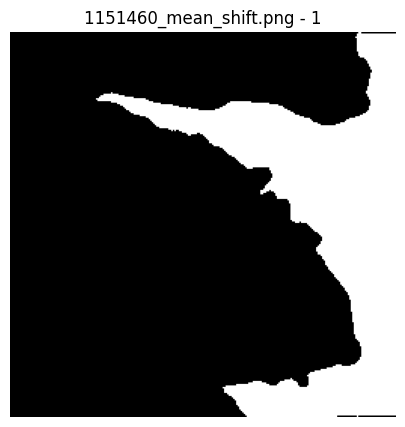

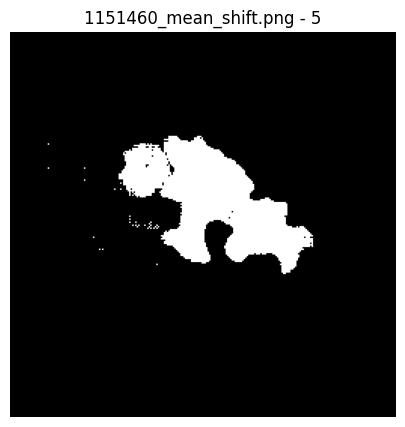

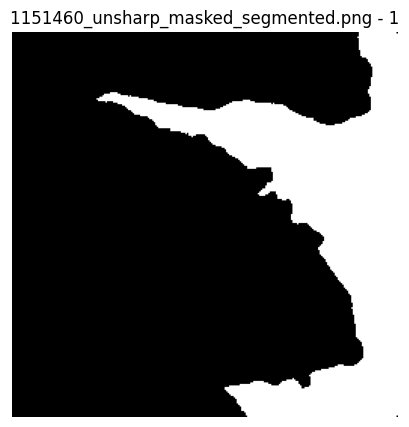

In [ ]:
# mask converter

et = ElementTree.parse('./data/png_images/preprocessed/preprocessing_test/annotations.xml')

labels_dict, colormap_dict = load_labels('./data/png_images/preprocessed/preprocessing_test/annotations.xml', zero_indexed=False, return_colormap=True)


# ref.: https://www.kaggle.com/stainsby/fast-tested-rle
def mask_to_rle(img: np.ndarray) -> str:
    """
    img: numpy array, 1 - mask, 0 - background
    Returns run length as string formatted
    """
    pixels = img.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

def rle_to_mask(
    mask_rle: str, 
    label: int, 
    mask_height: int, # height of the mask
    mask_width: int, # width of the mask
    top: int=0, # top coordinate of the mask where it begins
    left: int=0, # left coordinate of the mask where it begins
    img_height: int=256, 
    img_width: int=256
) -> np.ndarray:
    
    mask_rle_arr = np.array(mask_rle.split(', '), dtype=np.uint32) 
    sub_mask = np.zeros(mask_height * mask_width, dtype=np.uint8)
    
    start_idx = 0
    for i in range(len(mask_rle_arr)):
        if i % 2 == 1:
            start_idx += mask_rle_arr[i-1]
            length = mask_rle_arr[i]
            sub_mask[start_idx:start_idx+length] = label
            start_idx += length
    
    sub_mask = sub_mask.reshape((mask_height, mask_width))
    mask = np.zeros((img_height, img_width), dtype=np.uint8)
    mask[top:top+mask_height, left:left+mask_width] = sub_mask
    
    return mask

annotations_list = []
image_annotations = list(et.iterfind('image'))
for image_annotation in image_annotations:
    image_name = image_annotation.get('name')
    image_width = int(image_annotation.get('width'))
    image_height = int(image_annotation.get('height'))
    # print(image_name)
    for mask in image_annotation.iterfind('mask'):
        mask_rle = mask.get('rle')
        mask_width = int(mask.get('width'))
        mask_height = int(mask.get('height'))
        top = int(mask.get('top'))
        left = int(mask.get('left'))
        label = labels_dict[mask.get('label')]
        mask = rle_to_mask(mask_rle, label, mask_height, mask_width, top, left, image_height, image_width)

        fig, ax = plt.subplots(1, 1, figsize=(10, 5))
        ax.imshow(mask, cmap='gray')
        ax.set_title(f'{image_name} - {label}')
        ax.axis('off')
        